# Stock Market Trend Analysis: Moving Averages and Trends

This notebook calculates 20-day, 50-day, and 200-day simple moving averages from the cleaned Close prices for AAPL, MSFT, GOOGL, AMZN, and NVDA. It also detects descriptive SMA20/SMA50 crossovers and classifies the latest moving-average relationship.

Trend classifications and crossover labels are descriptive only. They are not Buy, Sell, or Hold recommendations, and no strategy returns are simulated.

## Objective

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.trend_analysis import (
    FIGURES_DIR,
    SMA_WINDOWS,
    TICKERS,
    build_trend_analysis,
    independent_crossover_sanity_check,
    independent_sma_sanity_check,
    plot_crossovers,
    plot_moving_averages,
    save_trend_outputs,
)

trend_data, trend_summary = build_trend_analysis()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("Loaded cleaned Phase 3 data and calculated Phase 6 trend measures.")

Loaded cleaned Phase 3 data and calculated Phase 6 trend measures.


## Moving-average validation

In [2]:
for ticker, data in trend_data.items():
    assert data["SMA20"].iloc[:19].isna().all()
    assert data["SMA50"].iloc[:49].isna().all()
    assert data["SMA200"].iloc[:199].isna().all()
    assert data[["SMA20", "SMA50", "SMA200"]].iloc[-1].notna().all()
maximum_sma_difference = independent_sma_sanity_check(trend_data)
assert maximum_sma_difference <= 1e-10
print(f"SMA20, SMA50, and SMA200 initial NaN checks: PASS")
print(f"Independent SMA sanity check: PASS (maximum difference {maximum_sma_difference:.3e})")

SMA20, SMA50, and SMA200 initial NaN checks: PASS
Independent SMA sanity check: PASS (maximum difference 1.137e-13)


## Close price and moving averages

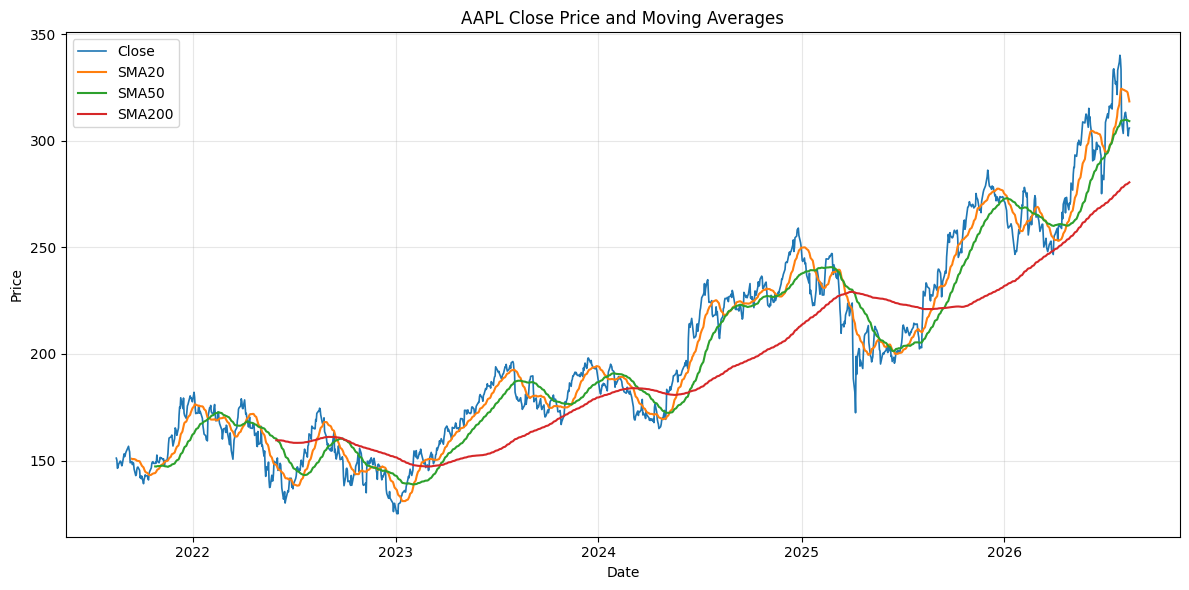

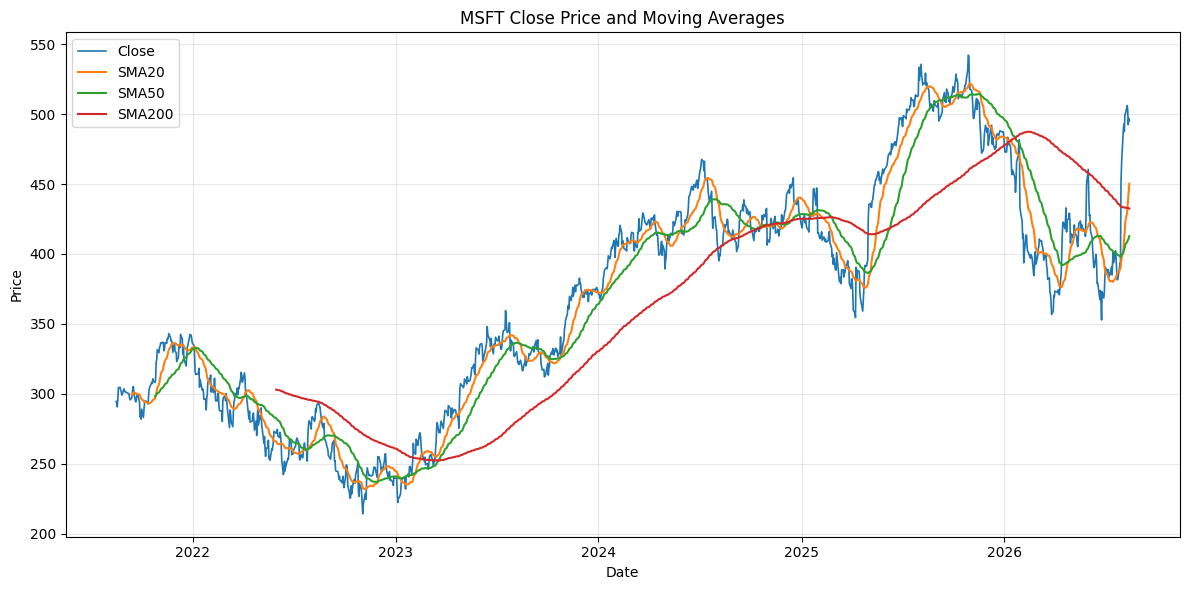

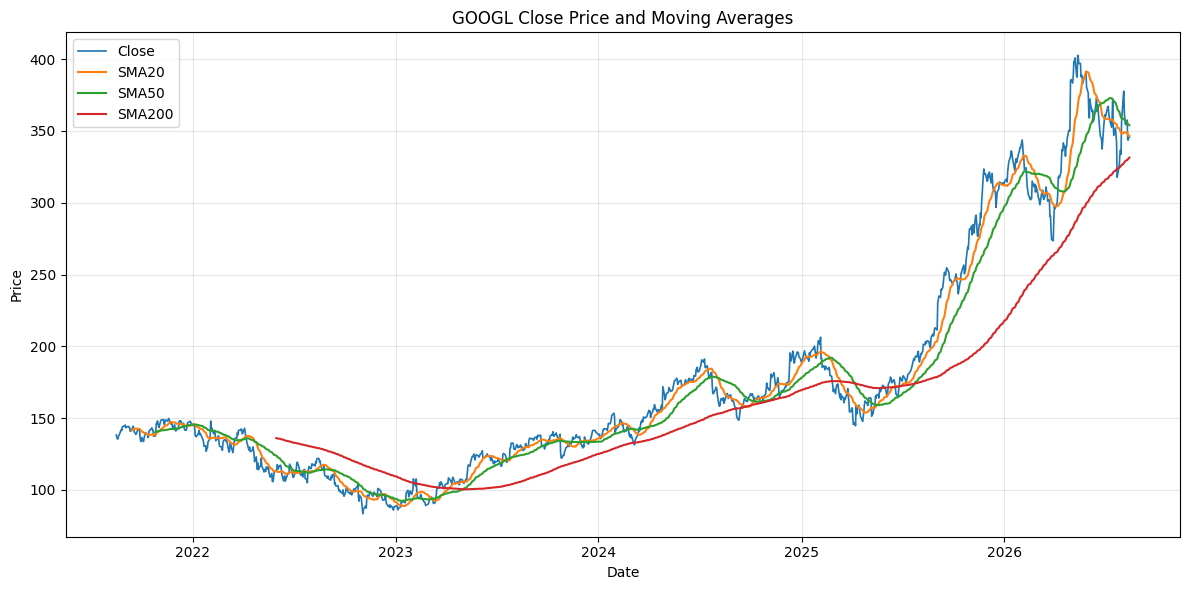

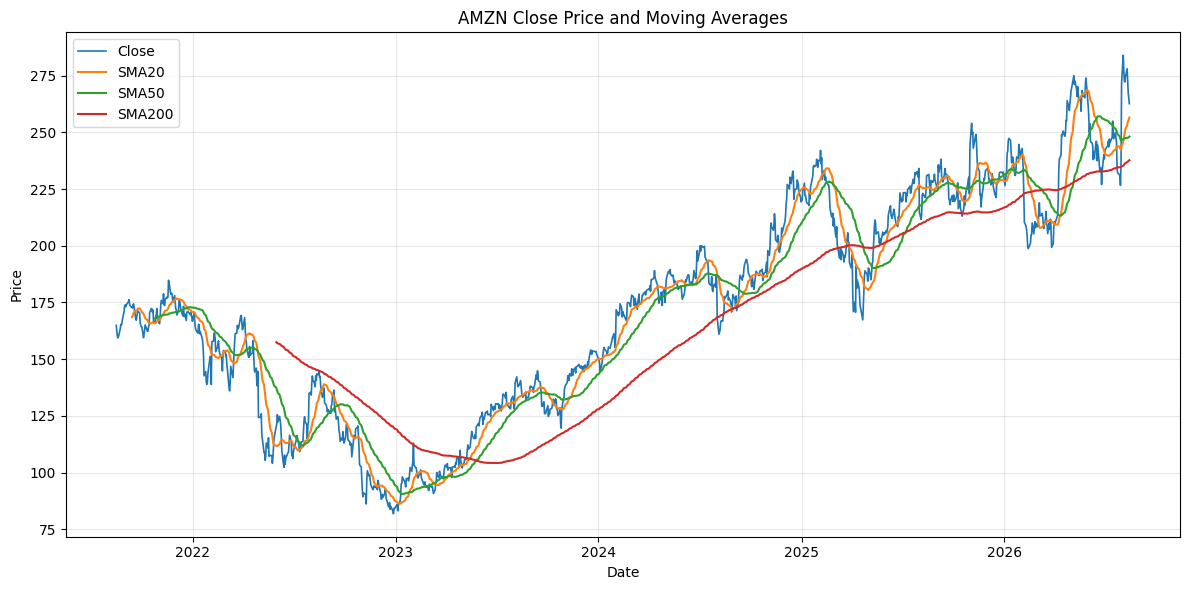

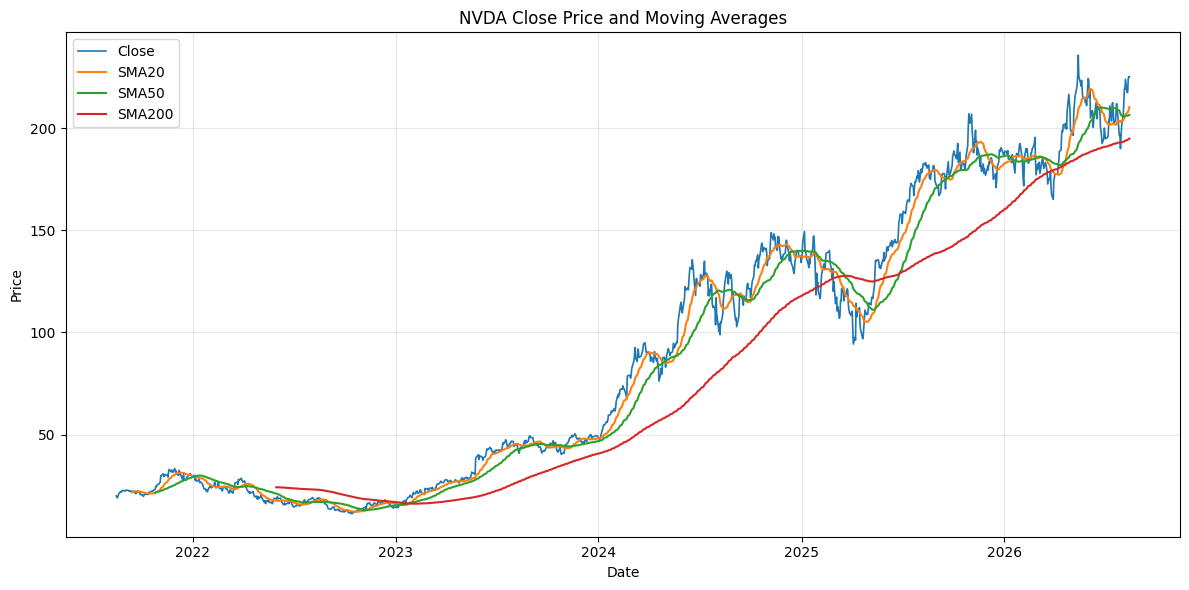

In [3]:
for ticker in TICKERS:
    figure = plot_moving_averages(ticker, trend_data[ticker], FIGURES_DIR / f"trend_{ticker}_moving_averages.png")
    display(figure)
    plt.close(figure)

## SMA20/SMA50 crossover detection

Crossover sanity check: PASS


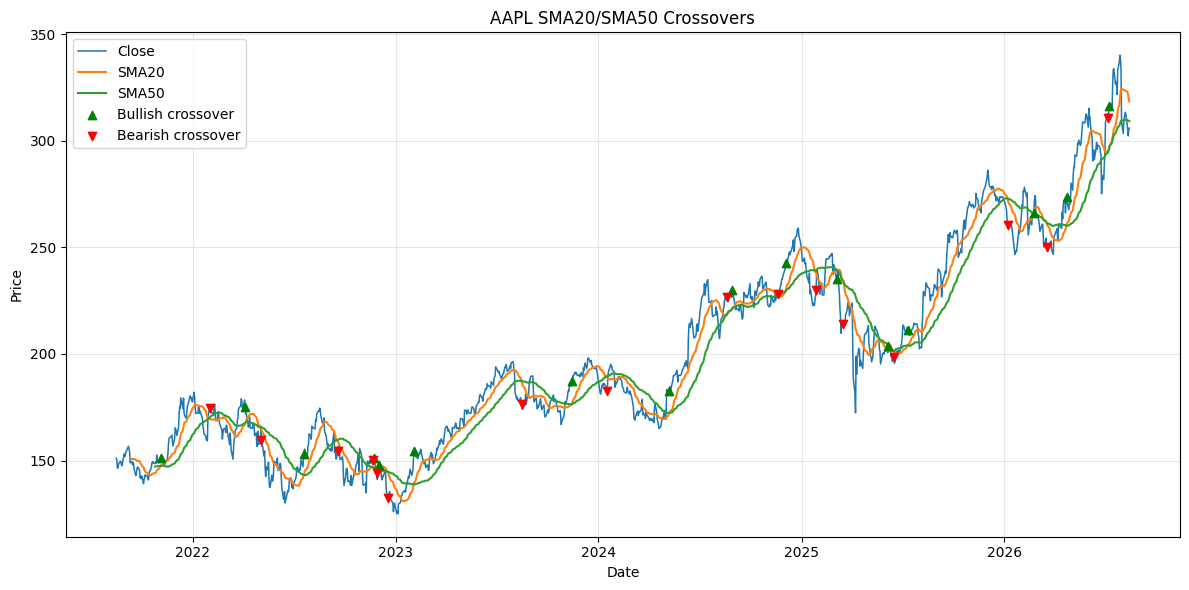

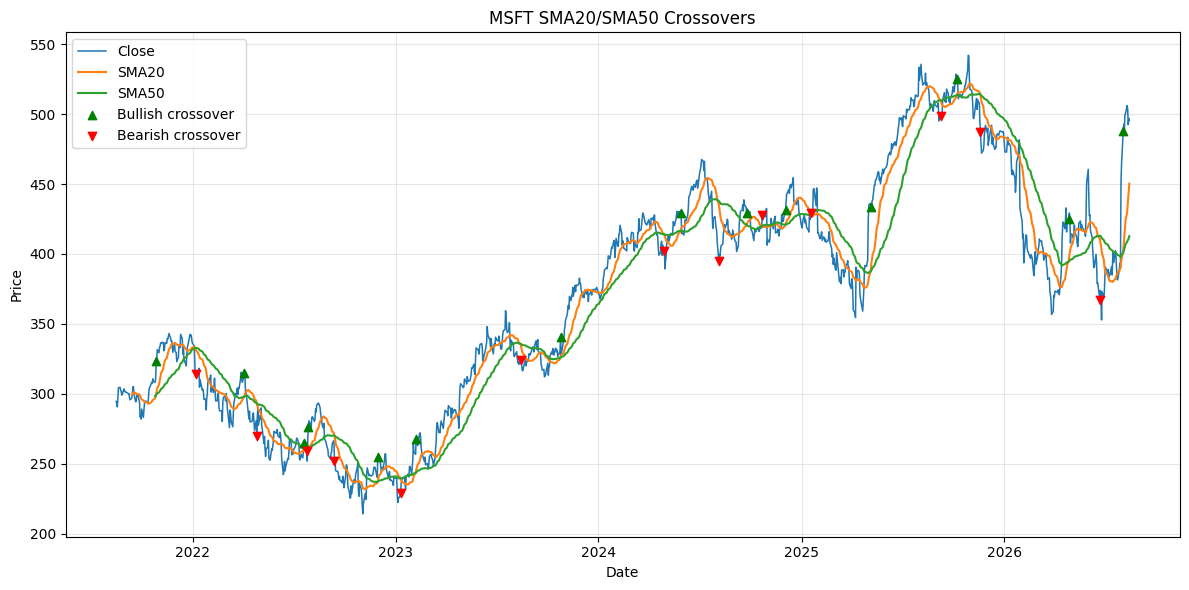

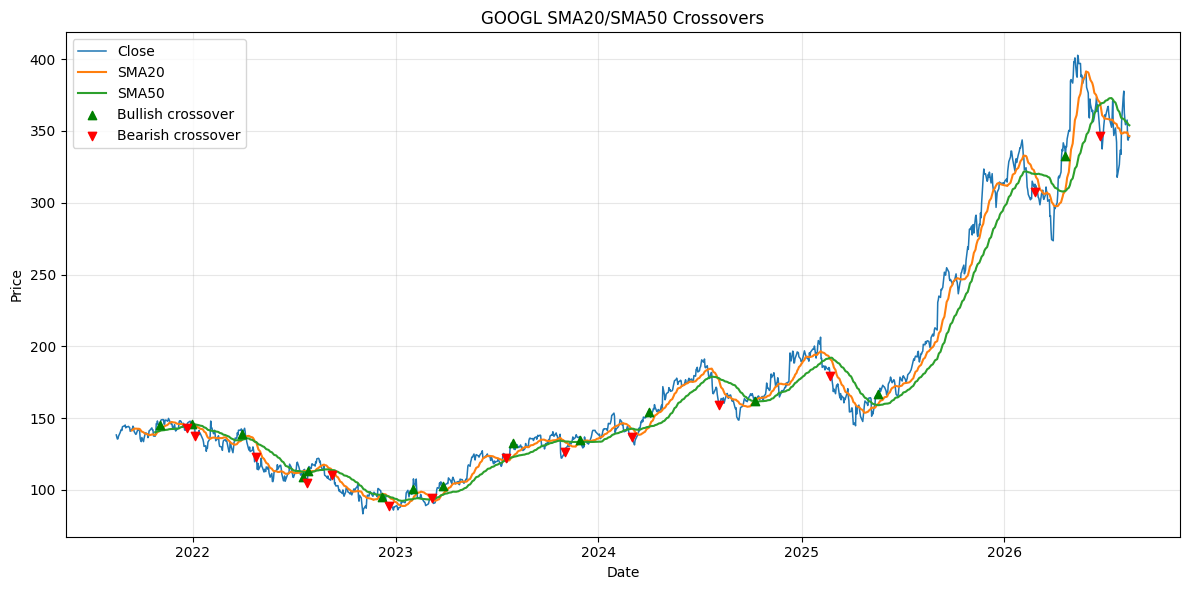

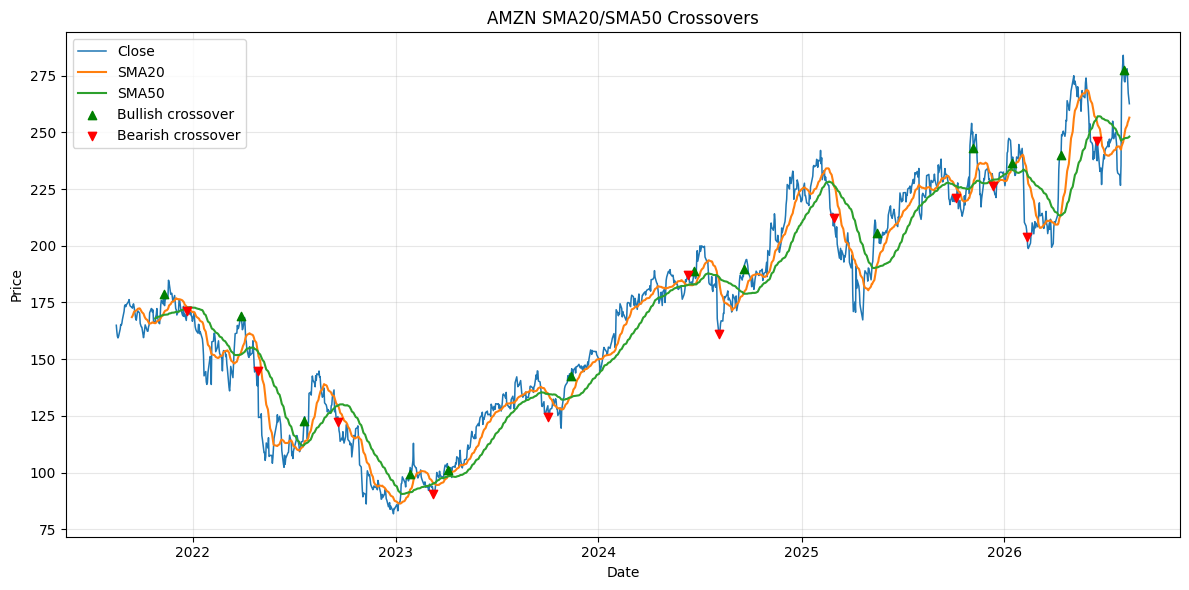

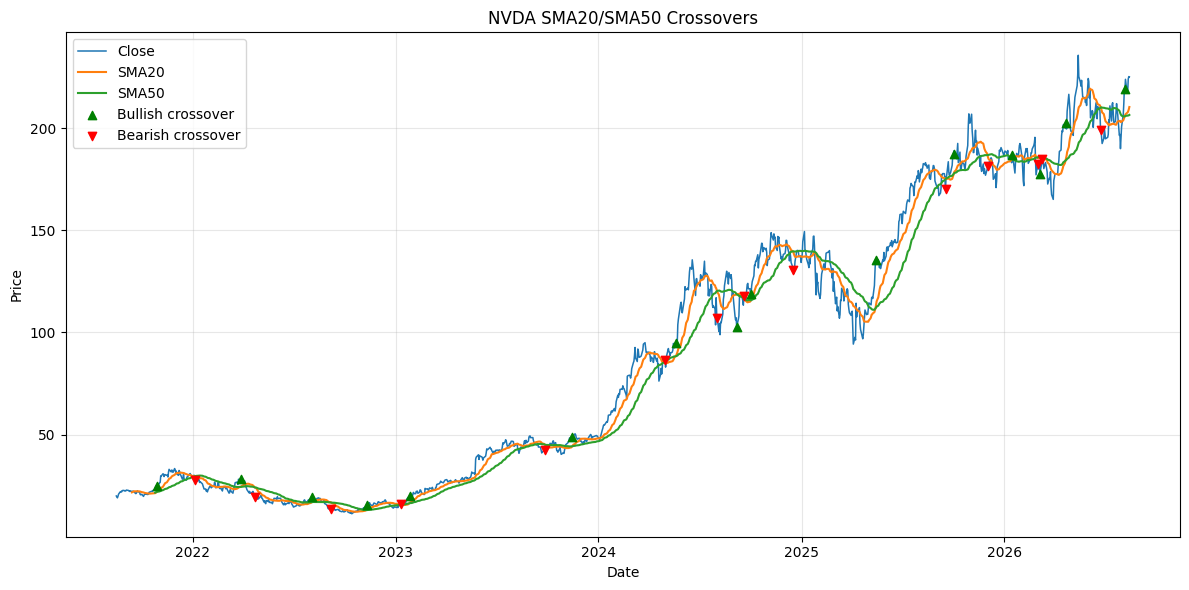

In [4]:
independent_crossover_sanity_check(trend_data)
print("Crossover sanity check: PASS")
for ticker in TICKERS:
    figure = plot_crossovers(ticker, trend_data[ticker], FIGURES_DIR / f"trend_{ticker}_crossovers.png")
    display(figure)
    plt.close(figure)

## Latest trend classification and summary

In [5]:
display(trend_summary.round(6))
_ = save_trend_outputs(trend_data, trend_summary)

,Latest Close,SMA20,SMA50,SMA200,Close vs SMA200 (%),Trend Classification,Bullish Crossovers,Bearish Crossovers,Latest Crossover Date,Latest Crossover Type
Stock,,,,,,,,,,
AAPL,305.929993,318.428500,309.190800,280.483650,9.072309,Mixed,16,16,2026-07-09,Bullish
MSFT,495.399994,450.240999,412.775598,432.480500,14.548516,Mixed,14,13,2026-08-03,Bullish
GOOGL,345.899994,346.409496,353.894399,331.375399,4.383124,Mixed,14,14,2026-06-23,Bearish
AMZN,262.649994,256.519500,248.166599,237.702450,10.495283,Bullish,13,12,2026-08-04,Bullish
NVDA,225.160004,210.394999,206.519599,194.919750,15.514207,Bullish,15,14,2026-08-06,Bullish


## Key Observations

The observations below are generated directly from the latest moving averages and detected historical crossovers. They are descriptive and are not trading recommendations.

In [6]:
for ticker, row in trend_summary.iterrows():
    print(
        f"{ticker}: {row['Trend Classification']}; Close vs SMA200 = {row['Close vs SMA200 (%)']:.2f}%; "
        f"bullish crossovers = {int(row['Bullish Crossovers'])}; bearish crossovers = {int(row['Bearish Crossovers'])}; "
        f"latest crossover = {row['Latest Crossover Type'] or 'None'} on {row['Latest Crossover Date'] or 'N/A'}"
    )
print("These are descriptive historical observations only.")

AAPL: Mixed; Close vs SMA200 = 9.07%; bullish crossovers = 16; bearish crossovers = 16; latest crossover = Bullish on 2026-07-09
MSFT: Mixed; Close vs SMA200 = 14.55%; bullish crossovers = 14; bearish crossovers = 13; latest crossover = Bullish on 2026-08-03
GOOGL: Mixed; Close vs SMA200 = 4.38%; bullish crossovers = 14; bearish crossovers = 14; latest crossover = Bearish on 2026-06-23
AMZN: Bullish; Close vs SMA200 = 10.50%; bullish crossovers = 13; bearish crossovers = 12; latest crossover = Bullish on 2026-08-04
NVDA: Bullish; Close vs SMA200 = 15.51%; bullish crossovers = 15; bearish crossovers = 14; latest crossover = Bullish on 2026-08-06
These are descriptive historical observations only.
